<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


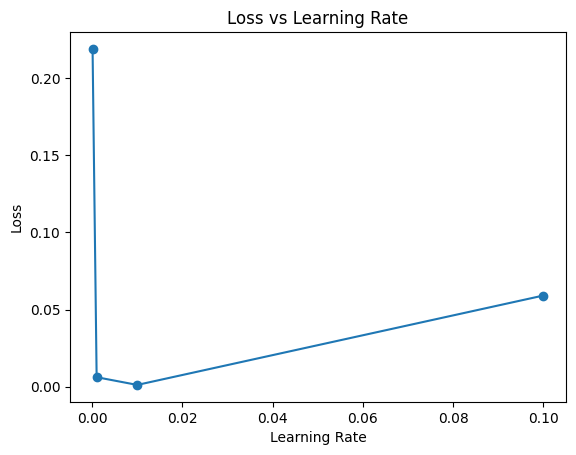

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_digits()
X = data.data
y = data.target

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []

for lr in learning_rates:
    model = MLPClassifier(hidden_layer_sizes=(64,),
                          learning_rate_init=lr,
                          max_iter=200,
                          random_state=42)

    model.fit(X_train, y_train)
    losses.append(model.loss_)

# Plot
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

Learning Rate: 0.001  -> Final Loss: 0.42256851334728185
Learning Rate: 0.01  -> Final Loss: 0.24274778947731063
Learning Rate: 0.05  -> Final Loss: 0.03129735873972159
Learning Rate: 0.1  -> Final Loss: 0.00514792300498625
Learning Rate: 0.5  -> Final Loss: 0.0004768523065732318
Learning Rate: 1  -> Final Loss: 0.00021132180391797033


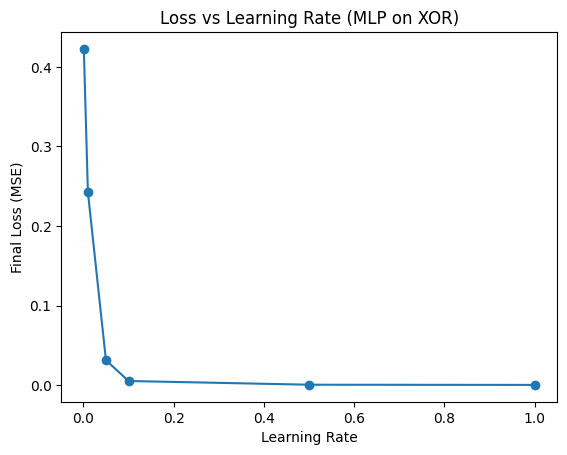

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# XOR Dataset
# -----------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# MLP Training Function
# -----------------------------
def train_mlp(learning_rate, epochs=5000):

    np.random.seed(42)

    # Initialize weights and biases
    W1 = np.random.randn(2, 4)
    b1 = np.random.randn(1, 4)

    W2 = np.random.randn(4, 1)
    b2 = np.random.randn(1, 1)

    for _ in range(epochs):

        # Forward Pass
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        output = sigmoid(z2)

        # Compute Loss (Mean Squared Error)
        loss = np.mean((y - output) ** 2)

        # Backpropagation
        d_output = (output - y) * sigmoid_derivative(output)

        d_W2 = np.dot(a1.T, d_output)
        d_b2 = np.sum(d_output, axis=0, keepdims=True)

        d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(a1)

        d_W1 = np.dot(X.T, d_hidden)
        d_b1 = np.sum(d_hidden, axis=0, keepdims=True)

        # Update weights
        W2 -= learning_rate * d_W2
        b2 -= learning_rate * d_b2

        W1 -= learning_rate * d_W1
        b1 -= learning_rate * d_b1

    return loss

# -----------------------------
# Test Different Learning Rates
# -----------------------------
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1]

losses = []

for lr in learning_rates:
    final_loss = train_mlp(lr)
    losses.append(final_loss)
    print(f"Learning Rate: {lr}  -> Final Loss: {final_loss}")

# -----------------------------
# Plot Graph
# -----------------------------
plt.figure()
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Loss vs Learning Rate (MLP on XOR)")
plt.show()

Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

In [2]:
model = MLPClassifier(hidden_layer_sizes=(64,),
                      solver='sgd',
                      learning_rate_init=0.01,
                      max_iter=200,
                      random_state=42)

model.fit(X_train, y_train)

print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9833333333333333


Final Predictions:
[[0.05988708]
 [0.92720291]
 [0.92945082]
 [0.0820282 ]]

Final Loss: 0.00514792300498625


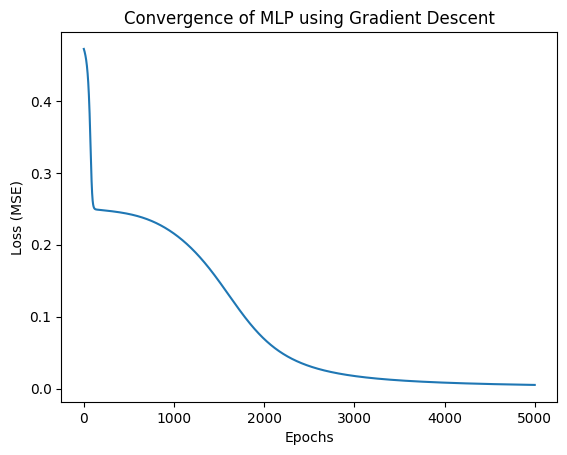

In [ ]:
# MLP using Gradient Descent (XOR Problem)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset (XOR)
# -----------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

# -----------------------------
# Activation Functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# Initialize Parameters
# -----------------------------
np.random.seed(42)

W1 = np.random.randn(2, 4)
b1 = np.random.randn(1, 4)

W2 = np.random.randn(4, 1)
b2 = np.random.randn(1, 1)

learning_rate = 0.1
epochs = 5000

loss_history = []

# -----------------------------
# Gradient Descent Training
# -----------------------------
for epoch in range(epochs):

    # Forward Pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)

    # Compute Loss (MSE)
    loss = np.mean((y - output) ** 2)
    loss_history.append(loss)

    # Backpropagation
    d_output = (output - y) * sigmoid_derivative(output)

    d_W2 = np.dot(a1.T, d_output)
    d_b2 = np.sum(d_output, axis=0, keepdims=True)

    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(a1)

    d_W1 = np.dot(X.T, d_hidden)
    d_b1 = np.sum(d_hidden, axis=0, keepdims=True)

    # Gradient Descent Update
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2

    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1

# -----------------------------
# Final Output
# -----------------------------
print("Final Predictions:")
print(output)

print("\nFinal Loss:", loss_history[-1])

# -----------------------------
# Plot Convergence Graph
# -----------------------------
plt.figure()
plt.plot(range(epochs), loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()

Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_digits()
X = data.data
y = data.target

# Scaling (VERY IMPORTANT for perceptron)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

print("Learning Rate Analysis:\n")

for lr in learning_rates:
    model = Perceptron(eta0=lr,
                       max_iter=1000,
                       tol=1e-3,
                       random_state=42)

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"Learning Rate: {lr}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("-"*40)

Learning Rate Analysis:

Learning Rate: 0.0001
Train Accuracy: 0.9631
Test Accuracy: 0.9500
----------------------------------------
Learning Rate: 0.001
Train Accuracy: 0.9624
Test Accuracy: 0.9472
----------------------------------------
Learning Rate: 0.01
Train Accuracy: 0.9743
Test Accuracy: 0.9389
----------------------------------------
Learning Rate: 0.1
Train Accuracy: 0.9701
Test Accuracy: 0.9472
----------------------------------------


In [2]:
model = Perceptron(
    eta0=0.01,          # learning rate
    max_iter=1000,      # number of iterations
    tol=1e-3,           # stopping criterion
    penalty=None,       # L1, L2 or None
    alpha=0.0001,       # regularization strength
    fit_intercept=True, # bias
    shuffle=True,       # shuffle data
    random_state=42
)

model.fit(X_train, y_train)

print("Final Accuracy:", model.score(X_test, y_test))

Final Accuracy: 0.9388888888888889


Learning Rate: 0.0001  -> Test Accuracy: 0.7555555555555555
Learning Rate: 0.001  -> Test Accuracy: 0.7555555555555555
Learning Rate: 0.01  -> Test Accuracy: 0.7555555555555555
Learning Rate: 0.1  -> Test Accuracy: 0.8
Learning Rate: 1  -> Test Accuracy: 0.8


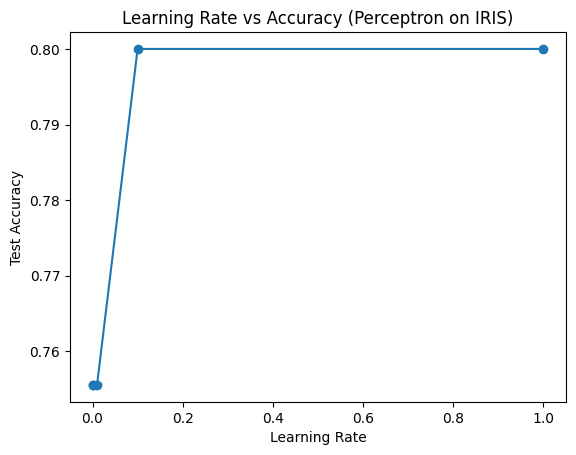

In [ ]:
# Perceptron on IRIS Dataset - Learning Rate Analysis

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Scaling (important for Perceptron)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Try Different Learning Rates
# -----------------------------
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]
accuracies = []

for lr in learning_rates:
    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print("Learning Rate:", lr, " -> Test Accuracy:", acc)

# -----------------------------
# Plot Graph
# -----------------------------
plt.figure()
plt.plot(learning_rates, accuracies, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Learning Rate vs Accuracy (Perceptron on IRIS)")
plt.show()

Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Load data
data = load_digits()
X = data.data
y = data.target

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Different parameter combinations
configs = [
    {"lr":0.0001, "layers":(32,), "iter":200},
    {"lr":0.001,  "layers":(64,), "iter":200},
    {"lr":0.01,   "layers":(64,32), "iter":300},
    {"lr":0.1,    "layers":(128,64), "iter":300}
]

print("MLP Parameter Exploration:\n")

for cfg in configs:
    model = MLPClassifier(hidden_layer_sizes=cfg["layers"],
                          learning_rate_init=cfg["lr"],
                          max_iter=cfg["iter"],
                          random_state=42)

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"LR={cfg['lr']}, Layers={cfg['layers']}, Iter={cfg['iter']}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Test Acc: {test_acc:.4f}")
    print("-"*50)

MLP Parameter Exploration:



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR=0.0001, Layers=(32,), Iter=200
Train Acc: 0.9395
Test Acc: 0.9083
--------------------------------------------------
LR=0.001, Layers=(64,), Iter=200
Train Acc: 1.0000
Test Acc: 0.9833
--------------------------------------------------
LR=0.01, Layers=(64, 32), Iter=300
Train Acc: 1.0000
Test Acc: 0.9722
--------------------------------------------------
LR=0.1, Layers=(128, 64), Iter=300
Train Acc: 0.6207
Test Acc: 0.6361
--------------------------------------------------


Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=5)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9295 - loss: 0.2382
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9694 - loss: 0.1005
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9788 - loss: 0.0707
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9831 - loss: 0.0532
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0429
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9763 - loss: 0.0787
Test Accuracy: 0.9763000011444092
